In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    TimeSeriesSplit
)

from sklearn.base import clone

In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    TimeSeriesSplit
)

from sklearn.base import clone

In [3]:
# ============================================================
# 2. LOAD DATA
# ============================================================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Train shape: (24040, 13)
Test shape: (4800, 12)


,date,ticker,adj_close,volume,market_cap,shares_out,book_value,eps_ttm,revenue_ttm,total_assets,total_debt,operating_income,fwd_ret_1m
0,2020-10-31,SYN009,278.9991,6812628,1.227872e+11,440098777,4.636467e+10,10.4907,5.924061e+10,1.192192e+11,5.853298e+10,6.412437e+09,0.015452
1,2020-07-31,SYN016,102.5050,38860632,7.762499e+10,757280277,9.026712e+10,6.6534,6.331819e+10,8.382240e+10,2.899133e+10,6.997919e+09,-0.117729
2,2013-06-30,SYN038,95.2958,37384951,6.080033e+10,638017115,2.100099e+10,2.2089,3.801420e+10,5.674878e+10,NaN,1.957376e+09,-0.002813
3,2013-02-28,SYN065,127.8020,20569071,8.790809e+10,687846131,3.367075e+10,6.3810,9.673761e+10,8.908524e+10,3.077928e+10,NaN,0.104236
4,2016-08-31,SYN131,327.8955,4075846,7.395054e+10,225530769,1.844178e+11,20.1165,4.957154e+10,8.614449e+10,3.359848e+10,6.301234e+09,-0.041793


,date,ticker,adj_close,volume,market_cap,shares_out,book_value,eps_ttm,revenue_ttm,total_assets,total_debt,operating_income
0,2023-01-31,SYN000,43.7081,38069445,2.441311e+10,558548692,1.336613e+10,1.6241,3.060112e+10,4.034892e+10,1.460123e+10,1.259952e+09
1,2023-01-31,SYN001,168.3102,9529507,2.656287e+10,157820865,5.461130e+09,6.1140,1.445860e+10,1.842953e+10,8.243181e+09,NaN
2,2023-01-31,SYN002,228.5195,13495262,4.092723e+10,179097302,NaN,20.9316,2.856504e+10,4.154607e+10,4.002268e+09,NaN
3,2023-01-31,SYN003,409.4659,49082611,2.860256e+11,698533300,1.567463e+11,8.2561,1.281355e+11,2.531850e+11,9.158887e+10,8.009924e+09
4,2023-01-31,SYN004,165.5143,28494061,8.610127e+10,520204396,2.830388e+10,NaN,6.251175e+10,8.683025e+10,3.331510e+10,1.804234e+09


In [4]:
# ============================================================
# 3. DATE HANDLING
# ============================================================

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

train = (
    train
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

test = (
    test
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

print(
    "Train:",
    train["date"].min(),
    "to",
    train["date"].max()
)

print(
    "Test:",
    test["date"].min(),
    "to",
    test["date"].max()
)

Train: 2013-01-31 00:00:00 to 2022-12-31 00:00:00
Test: 2023-01-31 00:00:00 to 2024-12-31 00:00:00


In [5]:
# ============================================================
# 5. MISSING VALUES
# ============================================================

missing = pd.DataFrame({
    "count": train.isna().sum(),
    "percentage": train.isna().mean() * 100
})

display(
    missing.sort_values(
        "percentage",
        ascending=False
    )
)

,count,percentage
eps_ttm,1718,7.146423
operating_income,1706,7.096506
book_value,1659,6.900998
total_debt,1648,6.855241
date,0,0.000000
ticker,0,0.000000
adj_close,0,0.000000
volume,0,0.000000
market_cap,0,0.000000
shares_out,0,0.000000


In [6]:
# ============================================================
# 5. MISSING VALUES
# ============================================================

missing = pd.DataFrame({
    "count": train.isna().sum(),
    "percentage": train.isna().mean() * 100
})

display(
    missing.sort_values(
        "percentage",
        ascending=False
    )
)

,count,percentage
eps_ttm,1718,7.146423
operating_income,1706,7.096506
book_value,1659,6.900998
total_debt,1648,6.855241
date,0,0.000000
ticker,0,0.000000
adj_close,0,0.000000
volume,0,0.000000
market_cap,0,0.000000
shares_out,0,0.000000


In [7]:
# ============================================================
# 6. DUPLICATE DATE-TICKER ROWS
# ============================================================

duplicate_count = (
    train
    .duplicated(
        subset=["date", "ticker"],
        keep=False
    )
    .sum()
)

print(
    "Duplicate date-ticker rows:",
    duplicate_count
)

train = (
    train
    .drop_duplicates(
        subset=["date", "ticker"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Train shape after deduplication:",
    train.shape
)

Duplicate date-ticker rows: 80
Train shape after deduplication: (24000, 13)


count    24000.000000
mean         0.012491
std          0.084487
min         -0.338473
25%         -0.044121
50%          0.012098
75%          0.068690
max          0.351937
Name: fwd_ret_1m, dtype: float64


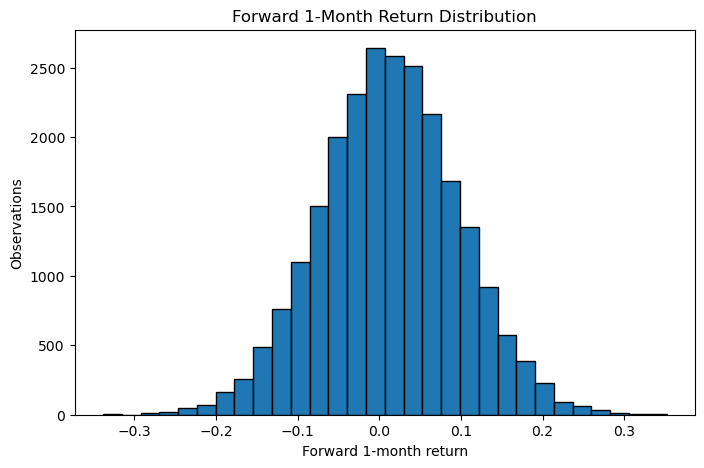

In [8]:
# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

print(
    train["fwd_ret_1m"].describe()
)

plt.figure(figsize=(8, 5))

plt.hist(
    train["fwd_ret_1m"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("Forward 1-month return")
plt.ylabel("Observations")
plt.title("Forward 1-Month Return Distribution")

plt.show()

In [9]:
# ============================================================
# 9. COMBINE TRAIN + TEST
# ============================================================

train["dataset"] = "train"
test["dataset"] = "test"

all_data = pd.concat(
    [
        train,
        test
    ],
    ignore_index=True
)

all_data = (
    all_data
    .sort_values(
        ["ticker", "date"]
    )
    .reset_index(drop=True)
)

print(
    "Combined shape:",
    all_data.shape
)

Combined shape: (28800, 14)


In [10]:
# ============================================================
# 10. RETURN FEATURES
# ============================================================

all_data["ret_1m"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .pct_change(1)
)

all_data["ret_3m"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .pct_change(3)
)

all_data["ret_6m"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .pct_change(6)
)

all_data["ret_12m"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .pct_change(12)
)

In [11]:
# ============================================================
# 11. 12-1 MOMENTUM
# ============================================================
# Uses the return from 12 months ago to 1 month ago,
# skipping the most recent month.

all_data["price_1m_ago"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .shift(1)
)

all_data["price_12m_ago"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .shift(12)
)

all_data["mom_12_1"] = (
    all_data["price_1m_ago"]
    /
    all_data["price_12m_ago"]
    - 1
)

print(
    all_data[
        [
            "date",
            "ticker",
            "mom_12_1"
        ]
    ].head(10)
)

        date  ticker  mom_12_1
0 2013-01-31  SYN000       NaN
1 2013-02-28  SYN000       NaN
2 2013-03-31  SYN000       NaN
3 2013-04-30  SYN000       NaN
4 2013-05-31  SYN000       NaN
5 2013-06-30  SYN000       NaN
6 2013-07-31  SYN000       NaN
7 2013-08-31  SYN000       NaN
8 2013-09-30  SYN000       NaN
9 2013-10-31  SYN000       NaN


In [12]:
# ============================================================
# 12. 3-MONTH REVERSAL
# ============================================================

all_data["price_ma_3m"] = (
    all_data
    .groupby("ticker")["adj_close"]
    .transform(
        lambda x:
        x.rolling(
            window=3,
            min_periods=3
        ).mean()
    )
)

all_data["reversal_3m"] = -(
    all_data["adj_close"]
    /
    all_data["price_ma_3m"]
    - 1
)

In [13]:
# ============================================================
# 13. FUNDAMENTAL RATIOS
# ============================================================

all_data["book_to_market"] = (
    all_data["book_value"]
    /
    all_data["market_cap"]
)

all_data["pe_ratio"] = (
    all_data["adj_close"]
    /
    all_data["eps_ttm"]
)

all_data["pb_ratio"] = (
    all_data["adj_close"]
    *
    all_data["shares_out"]
    /
    all_data["book_value"]
)

all_data["ps_ratio"] = (
    all_data["market_cap"]
    /
    all_data["revenue_ttm"]
)

all_data["debt_to_assets"] = (
    all_data["total_debt"]
    /
    all_data["total_assets"]
)

all_data["debt_to_equity"] = (
    all_data["total_debt"]
    /
    all_data["book_value"]
)

all_data["roa"] = (
    all_data["operating_income"]
    /
    all_data["total_assets"]
)

all_data["operating_margin"] = (
    all_data["operating_income"]
    /
    all_data["revenue_ttm"]
)

all_data["log_market_cap"] = (
    np.log1p(
        all_data["market_cap"]
    )
)

all_data["earnings_yield"] = (
    all_data["eps_ttm"]
    /
    all_data["adj_close"]
)

In [14]:
# ============================================================
# 14. RATIO DIAGNOSTICS
# ============================================================

ratio_cols = [
    "pb_ratio",
    "ps_ratio",
    "debt_to_assets",
    "debt_to_equity",
    "roa",
    "operating_margin",
    "log_market_cap",
    "earnings_yield"
]

display(
    all_data[ratio_cols].describe()
)

print("\nMissing percentage:")

display(
    (
        all_data[ratio_cols]
        .isna()
        .mean()
        * 100
    ).sort_values(
        ascending=False
    )
)

print("\nInfinite values:")

print(
    all_data[ratio_cols]
    .isin([np.inf, -np.inf])
    .sum()
)

,pb_ratio,ps_ratio,debt_to_assets,debt_to_equity,roa,operating_margin,log_market_cap,earnings_yield
count,26821.000000,28800.000000,26815.000000,24957.000000,26778.000000,26778.000000,28800.000000,26718.000000
mean,2.789928,1.479009,0.301014,1.061275,0.070079,0.122547,24.233438,0.063779
std,1.528662,0.803818,0.117997,0.841155,0.033366,0.085490,1.315606,0.035705
min,0.213076,0.285193,0.020000,0.025476,-0.084282,-0.170078,19.681985,-0.077096
25%,1.784389,0.987725,0.220565,0.530974,0.047731,0.070620,23.398579,0.039378
50%,2.474742,1.291068,0.299769,0.854999,0.070406,0.108045,24.342948,0.060323
75%,3.408032,1.714734,0.381887,1.363298,0.092280,0.154799,25.107407,0.084665
max,37.291980,9.614244,0.731055,19.934992,0.232673,0.852761,28.119247,0.332870



Missing percentage:


debt_to_equity      13.343750
earnings_yield       7.229167
roa                  7.020833
operating_margin     7.020833
debt_to_assets       6.892361
pb_ratio             6.871528
ps_ratio             0.000000
log_market_cap       0.000000
dtype: float64


Infinite values:
pb_ratio            0
ps_ratio            0
debt_to_assets      0
debt_to_equity      0
roa                 0
operating_margin    0
log_market_cap      0
earnings_yield      0
dtype: int64


In [33]:
# ============================================================
# 15. WINSORIZATION
# ============================================================

def winsorize_series(
    x,
    lower=0.01,
    upper=0.99
):
    low = x.quantile(lower)
    high = x.quantile(upper)

    return x.clip(
        lower=low,
        upper=high
    )


all_data["pb_ratio_w"] = (
    all_data
    .groupby("date")["pb_ratio"]
    .transform(
        winsorize_series
    )
)

all_data["earnings_yield_w"] = (
    all_data
    .groupby("date")["earnings_yield"]
    .transform(
        winsorize_series
    )
)

all_data["debt_to_equity_w"] = (
    all_data
    .groupby("date")["debt_to_equity"]
    .transform(
        winsorize_series
    )

)

print("Winsorization completed.")

Winsorization completed.


In [34]:
# ============================================================
# 16. CROSS-SECTIONAL Z-SCORES
# ============================================================

def cross_sectional_zscore(x):
    return (
        x - x.mean()
    ) / x.std()


zscore_cols = [
    "earnings_yield",
    "pb_ratio_w",
    "ps_ratio",
    "debt_to_assets",
    "debt_to_equity_w",
    "roa",
    "operating_margin",
    "log_market_cap",
    "reversal_3m"
]


for col in zscore_cols:

    all_data[col + "_z"] = (
        all_data
        .groupby("date")[col]
        .transform(
            cross_sectional_zscore
        )
    )


zscore_features = [
    "earnings_yield_z",
    "pb_ratio_w_z",
    "ps_ratio_z",
    "debt_to_assets_z",
    "debt_to_equity_w_z",
    "roa_z",
    "operating_margin_z",
    "log_market_cap_z",
    "reversal_3m_z"
]


all_data[zscore_features] = (
    all_data[zscore_features]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

print(
    "Z-score features created:",
    len(zscore_features)
)

Z-score features created: 9


In [35]:
# ============================================================
# 17. MISSINGNESS INDICATORS
# ============================================================

missing_cols = [
    "earnings_yield",
    "pb_ratio",
    "debt_to_assets",
    "debt_to_equity",
    "roa",
    "operating_margin"
]

for col in missing_cols:

    all_data[
        col + "_missing"
    ] = (
        all_data[col]
        .isna()
        .astype(int)
    )

print(
    "Missingness indicators created."
)

Missingness indicators created.


In [36]:
# ============================================================
# 18. ORIGINAL ML FEATURE SET
# ============================================================

fundamental_cols = [
    "earnings_yield_z",
    "pb_ratio_w_z",
    "ps_ratio_z",
    "debt_to_assets_z",
    "debt_to_equity_w_z",
    "roa_z",
    "operating_margin_z",
    "log_market_cap_z"
]

momentum_cols = [
    "ret_1m",
    "ret_3m",
    "ret_6m",
    "ret_12m"
]

feature_cols = (
    momentum_cols
    + fundamental_cols
    + ["reversal_3m_z"]
)

print(
    "Original feature count:",
    len(feature_cols)
)

print(feature_cols)

Original feature count: 13
['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'earnings_yield_z', 'pb_ratio_w_z', 'ps_ratio_z', 'debt_to_assets_z', 'debt_to_equity_w_z', 'roa_z', 'operating_margin_z', 'log_market_cap_z', 'reversal_3m_z']


In [19]:
# ============================================================
# 19. MISSINGNESS INDICATORS
# ============================================================

missing_cols = [
    "earnings_yield",
    "pb_ratio",
    "debt_to_assets",
    "debt_to_equity",
    "roa",
    "operating_margin"
]

for col in missing_cols:

    all_data[
        col + "_missing"
    ] = (
        all_data[col]
        .isna()
        .astype(int)
    )

In [37]:
# ============================================================
# 19. REFINED RETURN FEATURES
# ============================================================

return_cols = [
    "ret_1m",
    "ret_3m",
    "ret_6m"
]


for col in return_cols:

    all_data[
        col + "_missing"
    ] = (
        all_data[col]
        .isna()
        .astype(int)
    )

    all_data[
        col + "_z"
    ] = (
        all_data
        .groupby("date")[col]
        .transform(
            cross_sectional_zscore
        )
    )


# 12-1 momentum z-score
all_data["mom_12_1_z"] = (
    all_data
    .groupby("date")["mom_12_1"]
    .transform(
        cross_sectional_zscore
    )
)


refined_z_cols = [
    "ret_1m_z",
    "ret_3m_z",
    "ret_6m_z",
    "mom_12_1_z"
]


all_data[refined_z_cols] = (
    all_data[refined_z_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

print(
    "Refined return features created."
)

Refined return features created.


In [38]:
# ============================================================
# 20. FINAL ML FEATURE SET
# ============================================================

ml_feature_cols = [

    "ret_1m_z",
    "ret_3m_z",
    "ret_6m_z",

    "mom_12_1_z",

    "earnings_yield_z",
    "pb_ratio_w_z",
    "ps_ratio_z",

    "debt_to_assets_z",
    "debt_to_equity_w_z",

    "roa_z",
    "operating_margin_z",

    "log_market_cap_z",

    "reversal_3m_z",

    "ret_1m_missing",
    "ret_3m_missing",
    "ret_6m_missing"
]


# Final safety check
all_data[ml_feature_cols] = (
    all_data[ml_feature_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


print(
    "Final ML feature count:",
    len(ml_feature_cols)
)

print(
    "Remaining ML NaNs:",
    all_data[ml_feature_cols]
    .isna()
    .sum()
    .sum()
)

print(
    "\nFeatures:"
)

print(ml_feature_cols)

Final ML feature count: 16
Remaining ML NaNs: 0

Features:
['ret_1m_z', 'ret_3m_z', 'ret_6m_z', 'mom_12_1_z', 'earnings_yield_z', 'pb_ratio_w_z', 'ps_ratio_z', 'debt_to_assets_z', 'debt_to_equity_w_z', 'roa_z', 'operating_margin_z', 'log_market_cap_z', 'reversal_3m_z', 'ret_1m_missing', 'ret_3m_missing', 'ret_6m_missing']


In [39]:
# ============================================================
# 21. REBUILD PROCESSED DATASETS
# ============================================================

train_processed = (
    all_data[
        all_data["dataset"] == "train"
    ]
    .copy()
)

test_processed = (
    all_data[
        all_data["dataset"] == "test"
    ]
    .copy()
)

print(
    "Train processed:",
    train_processed.shape
)

print(
    "Test processed:",
    test_processed.shape
)

Train processed: (24000, 58)
Test processed: (4800, 58)


In [40]:
# ============================================================
# 22. ML DATASET
# ============================================================

train_ml = (
    train_processed
    .dropna(
        subset=["fwd_ret_1m"]
    )
    .copy()
)

test_ml = (
    test_processed
    .copy()
)

print(
    "Train ML:",
    train_ml.shape
)

print(
    "Test ML:",
    test_ml.shape
)

Train ML: (24000, 58)
Test ML: (4800, 58)


In [41]:
# ============================================================
# 23. CHRONOLOGICAL 80/20 SPLIT
# ============================================================

unique_dates = np.array(
    sorted(
        train_ml["date"].unique()
    )
)

split_idx = int(
    len(unique_dates) * 0.80
)

development_dates = (
    unique_dates[:split_idx]
)

validation_dates = (
    unique_dates[split_idx:]
)

train_data = (
    train_ml[
        train_ml["date"].isin(
            development_dates
        )
    ]
    .copy()
)

valid_data = (
    train_ml[
        train_ml["date"].isin(
            validation_dates
        )
    ]
    .copy()
)

print(
    "Development:",
    train_data.shape
)

print(
    "Validation:",
    valid_data.shape
)

print(
    "Development months:",
    len(development_dates)
)

print(
    "Validation months:",
    len(validation_dates)
)

Development: (19200, 58)
Validation: (4800, 58)
Development months: 96
Validation months: 24


In [42]:
# ============================================================
# 24. TRAIN / VALIDATION MATRICES
# ============================================================

X_tr = train_data[
    ml_feature_cols
]

y_tr = train_data[
    "fwd_ret_1m"
]

X_val = valid_data[
    ml_feature_cols
]

y_val = valid_data[
    "fwd_ret_1m"
]

X_test = test_ml[
    ml_feature_cols
]


print(
    "X_train:",
    X_tr.shape
)

print(
    "y_train:",
    y_tr.shape
)

print(
    "X_validation:",
    X_val.shape
)

print(
    "y_validation:",
    y_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "\nTrain NaNs:",
    X_tr.isna().sum().sum()
)

print(
    "Validation NaNs:",
    X_val.isna().sum().sum()
)

print(
    "Test NaNs:",
    X_test.isna().sum().sum()
)

X_train: (19200, 16)
y_train: (19200,)
X_validation: (4800, 16)
y_validation: (4800,)
X_test: (4800, 16)

Train NaNs: 0
Validation NaNs: 0
Test NaNs: 0


In [44]:
# ============================================================
# 25. PORTFOLIO EVALUATION
# ============================================================

def evaluate_score(df, score_col="score"):

    data = df[
        ["date", "ticker", score_col, "fwd_ret_1m"]
    ].dropna(
        subset=[score_col, "fwd_ret_1m"]
    ).copy()

    monthly_returns = []
    monthly_turnover = []
    monthly_ic = []

    previous_weights = None

    for date, month in data.groupby("date"):

        month = month.copy()

        month["rank"] = (
            month[score_col]
            .rank(
                pct=True,
                method="first"
            )
        )

        long_mask = month["rank"] >= 0.90
        short_mask = month["rank"] <= 0.10

        month["weight"] = 0.0

        if long_mask.sum() > 0:
            month.loc[
                long_mask,
                "weight"
            ] = 1.0 / long_mask.sum()

        if short_mask.sum() > 0:
            month.loc[
                short_mask,
                "weight"
            ] = -1.0 / short_mask.sum()

        long_return = (
            month.loc[
                long_mask,
                "fwd_ret_1m"
            ].mean()
        )

        short_return = (
            month.loc[
                short_mask,
                "fwd_ret_1m"
            ].mean()
        )

        gross_return = (
            long_return - short_return
        )

        current_weights = (
            month
            .set_index("ticker")["weight"]
        )

        if previous_weights is None:

            turnover = np.nan

        else:

            tickers = (
                previous_weights.index
                .union(current_weights.index)
            )

            current = (
                current_weights
                .reindex(
                    tickers,
                    fill_value=0
                )
            )

            previous = (
                previous_weights
                .reindex(
                    tickers,
                    fill_value=0
                )
            )

            turnover = (
                current
                .sub(previous)
                .abs()
                .sum()
            )

        ic = spearmanr(
            month[score_col],
            month["fwd_ret_1m"]
        ).statistic

        monthly_returns.append(
            gross_return
        )

        monthly_turnover.append(
            turnover
        )

        monthly_ic.append(
            ic
        )

        previous_weights = current_weights

    monthly_returns = np.asarray(
        monthly_returns,
        dtype=float
    )

    monthly_turnover = np.asarray(
        monthly_turnover,
        dtype=float
    )

    monthly_ic = np.asarray(
        monthly_ic,
        dtype=float
    )

    costs = (
        0.001
        * np.nan_to_num(
            monthly_turnover
        )
    )

    net_returns = (
        monthly_returns - costs
    )

    sharpe = (
        net_returns.mean()
        /
        net_returns.std()
        *
        np.sqrt(12)
    )

    rank_ic = np.nanmean(
        monthly_ic
    )

    icir = (
        rank_ic
        /
        np.nanstd(monthly_ic)
    )

    return {
        "Net Sharpe": sharpe,
        "Rank IC": rank_ic,
        "ICIR": icir,
        "Mean Turnover":
            np.nanmean(monthly_turnover),
        "Mean Net Return":
            np.nanmean(net_returns)
    }

In [45]:
# ============================================================
# 25. PORTFOLIO EVALUATION
# ============================================================

def evaluate_score(df, score_col="score"):

    data = df[
        ["date", "ticker", score_col, "fwd_ret_1m"]
    ].dropna(
        subset=[score_col, "fwd_ret_1m"]
    ).copy()

    monthly_returns = []
    monthly_turnover = []
    monthly_ic = []

    previous_weights = None

    for date, month in data.groupby("date"):

        month = month.copy()

        month["rank"] = (
            month[score_col]
            .rank(
                pct=True,
                method="first"
            )
        )

        long_mask = month["rank"] >= 0.90
        short_mask = month["rank"] <= 0.10

        month["weight"] = 0.0

        if long_mask.sum() > 0:
            month.loc[
                long_mask,
                "weight"
            ] = 1.0 / long_mask.sum()

        if short_mask.sum() > 0:
            month.loc[
                short_mask,
                "weight"
            ] = -1.0 / short_mask.sum()

        long_return = (
            month.loc[
                long_mask,
                "fwd_ret_1m"
            ].mean()
        )

        short_return = (
            month.loc[
                short_mask,
                "fwd_ret_1m"
            ].mean()
        )

        gross_return = (
            long_return - short_return
        )

        current_weights = (
            month
            .set_index("ticker")["weight"]
        )

        if previous_weights is None:

            turnover = np.nan

        else:

            tickers = (
                previous_weights.index
                .union(current_weights.index)
            )

            current = (
                current_weights
                .reindex(
                    tickers,
                    fill_value=0
                )
            )

            previous = (
                previous_weights
                .reindex(
                    tickers,
                    fill_value=0
                )
            )

            turnover = (
                current
                .sub(previous)
                .abs()
                .sum()
            )

        ic = spearmanr(
            month[score_col],
            month["fwd_ret_1m"]
        ).statistic

        monthly_returns.append(
            gross_return
        )

        monthly_turnover.append(
            turnover
        )

        monthly_ic.append(
            ic
        )

        previous_weights = current_weights

    monthly_returns = np.asarray(
        monthly_returns,
        dtype=float
    )

    monthly_turnover = np.asarray(
        monthly_turnover,
        dtype=float
    )

    monthly_ic = np.asarray(
        monthly_ic,
        dtype=float
    )

    costs = (
        0.001
        * np.nan_to_num(
            monthly_turnover
        )
    )

    net_returns = (
        monthly_returns - costs
    )

    sharpe = (
        net_returns.mean()
        /
        net_returns.std()
        *
        np.sqrt(12)
    )

    rank_ic = np.nanmean(
        monthly_ic
    )

    icir = (
        rank_ic
        /
        np.nanstd(monthly_ic)
    )

    return {
        "Net Sharpe": sharpe,
        "Rank IC": rank_ic,
        "ICIR": icir,
        "Mean Turnover":
            np.nanmean(monthly_turnover),
        "Mean Net Return":
            np.nanmean(net_returns)
    }

In [46]:
# ============================================================
# 26. MODEL DEFINITIONS
# ============================================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(alpha=1.0),

    "Lasso":
        Lasso(
            alpha=0.001,
            max_iter=20000
        ),

    "Elastic Net":
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=20000
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

In [47]:
# ============================================================
# 28. FACTOR COMPONENTS
# ============================================================

research_data = all_data.copy()

research_data["M"] = (
    research_data["mom_12_1_z"]
)

research_data["V"] = (
    research_data["earnings_yield_z"]
    - research_data["pb_ratio_w_z"]
    - research_data["ps_ratio_z"]
) / 3.0

research_data["Q"] = (
    research_data["roa_z"]
    + research_data["operating_margin_z"]
) / 2.0

research_data["L"] = (
    -research_data["debt_to_assets_z"]
    -research_data["debt_to_equity_w_z"]
) / 2.0

research_data["R"] = (
    research_data["reversal_3m_z"]
)

for col in [
    "M",
    "V",
    "Q",
    "L",
    "R"
]:

    research_data[col] = (
        research_data
        .groupby("date")[col]
        .transform(
            cross_sectional_zscore
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
    )

In [48]:
# ============================================================
# 28. FACTOR COMPONENTS
# ============================================================

research_data = all_data.copy()

research_data["M"] = (
    research_data["mom_12_1_z"]
)

research_data["V"] = (
    research_data["earnings_yield_z"]
    - research_data["pb_ratio_w_z"]
    - research_data["ps_ratio_z"]
) / 3.0

research_data["Q"] = (
    research_data["roa_z"]
    + research_data["operating_margin_z"]
) / 2.0

research_data["L"] = (
    -research_data["debt_to_assets_z"]
    -research_data["debt_to_equity_w_z"]
) / 2.0

research_data["R"] = (
    research_data["reversal_3m_z"]
)

for col in [
    "M",
    "V",
    "Q",
    "L",
    "R"
]:

    research_data[col] = (
        research_data
        .groupby("date")[col]
        .transform(
            cross_sectional_zscore
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
    )

In [49]:
# ============================================================
# 30. OFFICIAL BENCHMARK
# ============================================================

OFFICIAL_BENCHMARK_SHARPE = 1.78

print(
    "Official 12-1 Momentum Benchmark:",
    OFFICIAL_BENCHMARK_SHARPE
)

Official 12-1 Momentum Benchmark: 1.78


In [50]:
# ============================================================
# 31. INTERNAL TIME-SERIES FOLDS
# ============================================================

development = research_data[
    research_data["date"].isin(
        development_dates
    )
].copy()

development_dates_sorted = np.array(
    sorted(
        development["date"].unique()
    )
)

tscv = TimeSeriesSplit(
    n_splits=4,
    test_size=10
)

folds = []

for train_idx, val_idx in tscv.split(
    development_dates_sorted
):

    folds.append({

        "train_dates":
            set(
                development_dates_sorted[
                    train_idx
                ]
            ),

        "validation_dates":
            set(
                development_dates_sorted[
                    val_idx
                ]
            )
    })

print(
    "Internal folds:",
    len(folds)
)

Internal folds: 4


In [52]:
# ============================================================
# 32. INTERNAL MODEL / FACTOR SELECTION
# ============================================================

# Factor combinations used in the research stage
factor_specs = {

    "Factor_A": {
        "M": 0.50,
        "V": 0.20,
        "Q": 0.10,
        "L": 0.20,
        "R": 0.00
    },

    "Factor_B": {
        "M": 0.30,
        "V": 0.30,
        "Q": 0.30,
        "L": 0.00,
        "R": 0.10
    },

    "Factor_C": {
        "M": 0.60,
        "V": 0.20,
        "Q": 0.00,
        "L": 0.10,
        "R": 0.10
    }
}


def make_factor_score(df, spec):

    return (
        spec["M"] * df["M"]
        + spec["V"] * df["V"]
        + spec["Q"] * df["Q"]
        + spec["L"] * df["L"]
        + spec["R"] * df["R"]
    )


selection_results = []

for factor_name, factor_spec in factor_specs.items():

    print("\nTesting:", factor_name)

    for fold_number, fold in enumerate(
        folds,
        start=1
    ):

        fold_train = development[
            development["date"].isin(
                fold["train_dates"]
            )
        ].copy()

        fold_valid = development[
            development["date"].isin(
                fold["validation_dates"]
            )
        ].copy()

        # Build factor score
        fold_train["factor_score"] = (
            make_factor_score(
                fold_train,
                factor_spec
            )
        )

        fold_valid["factor_score"] = (
            make_factor_score(
                fold_valid,
                factor_spec
            )
        )

        # Normalize factor score within each month
        fold_train["factor_z"] = (
            fold_train
            .groupby("date")["factor_score"]
            .transform(
                cross_sectional_zscore
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .fillna(0)
        )

        fold_valid["factor_z"] = (
            fold_valid
            .groupby("date")["factor_score"]
            .transform(
                cross_sectional_zscore
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .fillna(0)
        )

        # Test each ML model
        for model_name, base_model in models.items():

            model = clone(base_model)

            model.fit(
                fold_train[ml_feature_cols],
                fold_train["fwd_ret_1m"]
            )

            fold_valid["ml_raw"] = (
                model.predict(
                    fold_valid[ml_feature_cols]
                )
            )

            # Normalize ML prediction cross-sectionally
            fold_valid["ml_z"] = (
                fold_valid
                .groupby("date")["ml_raw"]
                .transform(
                    cross_sectional_zscore
                )
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .fillna(0)
            )

            # 90% factor + 10% ML
            fold_valid["final_score"] = (
                0.90 * fold_valid["factor_z"]
                + 0.10 * fold_valid["ml_z"]
            )

            metrics = evaluate_score(
                fold_valid,
                "final_score"
            )

            selection_results.append({

                "Fold":
                    fold_number,

                "Factor":
                    factor_name,

                "Model":
                    model_name,

                "Net Sharpe":
                    metrics["Net Sharpe"],

                "Rank IC":
                    metrics["Rank IC"],

                "ICIR":
                    metrics["ICIR"],

                "Mean Turnover":
                    metrics["Mean Turnover"]
            })

print("\nInternal selection completed.")

selection_results = pd.DataFrame(
    selection_results
)

display(
    selection_results.head()
)


Testing: Factor_A

Testing: Factor_B

Testing: Factor_C

Internal selection completed.


,Fold,Factor,Model,Net Sharpe,Rank IC,ICIR,Mean Turnover
0,1,Factor_A,Linear Regression,2.670443,0.020656,0.354405,1.226984
1,1,Factor_A,Ridge,2.670443,0.020645,0.354312,1.226984
2,1,Factor_A,Lasso,2.902846,0.021347,0.360580,1.216402
3,1,Factor_A,Elastic Net,2.710911,0.021463,0.363389,1.216931
4,1,Factor_A,Random Forest,2.413548,0.021506,0.375020,1.293651


In [53]:
# ============================================================
# 33. AGGREGATE INTERNAL RESULTS
# ============================================================

internal_summary = (
    selection_results
    .groupby(
        ["Factor", "Model"]
    )
    .agg(
        Mean_Sharpe=(
            "Net Sharpe",
            "mean"
        ),

        Median_Sharpe=(
            "Net Sharpe",
            "median"
        ),

        Mean_ICIR=(
            "ICIR",
            "mean"
        ),

        Mean_Rank_IC=(
            "Rank IC",
            "mean"
        ),

        Mean_Turnover=(
            "Mean Turnover",
            "mean"
        ),

        Worst_Fold_Sharpe=(
            "Net Sharpe",
            "min"
        )
    )
    .reset_index()
)

internal_summary = internal_summary.sort_values(
    [
        "Mean_Sharpe",
        "Mean_ICIR",
        "Mean_Rank_IC",
        "Worst_Fold_Sharpe"
    ],
    ascending=[
        False,
        False,
        False,
        False
    ]
)

display(
    internal_summary
)

,Factor,Model,Mean_Sharpe,Median_Sharpe,Mean_ICIR,Mean_Rank_IC,Mean_Turnover,Worst_Fold_Sharpe
4,Factor_A,Random Forest,2.511231,2.538747,0.582878,0.042561,1.271032,1.826810
15,Factor_C,Linear Regression,2.469311,2.514415,0.522253,0.036751,1.408995,0.777794
17,Factor_C,Ridge,2.469311,2.514415,0.522237,0.036750,1.408995,0.777794
3,Factor_A,Linear Regression,2.452054,2.557984,0.605588,0.043586,1.241138,1.832976
5,Factor_A,Ridge,2.452054,2.557984,0.605486,0.043581,1.241138,1.832976
13,Factor_C,Gradient Boosting,2.433796,2.466876,0.530777,0.037726,1.463492,0.604584
2,Factor_A,Lasso,2.389013,2.530473,0.604947,0.043578,1.243519,1.592262
0,Factor_A,Elastic Net,2.351010,2.569992,0.606916,0.043726,1.232937,1.553145
14,Factor_C,Lasso,2.302293,2.393886,0.524845,0.036648,1.417593,0.632023
1,Factor_A,Gradient Boosting,2.285980,2.335770,0.593697,0.044350,1.286640,1.638483


In [54]:
# ============================================================
# 34. LASSO BLEND SWEEP
# ============================================================

lasso_weights = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

lasso_results = []

for factor_name, factor_spec in factor_specs.items():

    for lasso_weight in lasso_weights:

        factor_weight = (
            1.0 - lasso_weight
        )

        fold_metrics = []

        for fold in folds:

            fold_train = development[
                development["date"].isin(
                    fold["train_dates"]
                )
            ].copy()

            fold_valid = development[
                development["date"].isin(
                    fold["validation_dates"]
                )
            ].copy()

            fold_train["factor_score"] = (
                make_factor_score(
                    fold_train,
                    factor_spec
                )
            )

            fold_valid["factor_score"] = (
                make_factor_score(
                    fold_valid,
                    factor_spec
                )
            )

            fold_train["factor_z"] = (
                fold_train
                .groupby("date")["factor_score"]
                .transform(
                    cross_sectional_zscore
                )
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .fillna(0)
            )

            fold_valid["factor_z"] = (
                fold_valid
                .groupby("date")["factor_score"]
                .transform(
                    cross_sectional_zscore
                )
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .fillna(0)
            )

            lasso = Lasso(
                alpha=0.001,
                max_iter=20000
            )

            lasso.fit(
                fold_train[ml_feature_cols],
                fold_train["fwd_ret_1m"]
            )

            fold_valid["lasso_raw"] = (
                lasso.predict(
                    fold_valid[ml_feature_cols]
                )
            )

            fold_valid["lasso_z"] = (
                fold_valid
                .groupby("date")["lasso_raw"]
                .transform(
                    cross_sectional_zscore
                )
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .fillna(0)
            )

            fold_valid["final_score"] = (
                factor_weight
                * fold_valid["factor_z"]
                +
                lasso_weight
                * fold_valid["lasso_z"]
            )

            metrics = evaluate_score(
                fold_valid,
                "final_score"
            )

            fold_metrics.append(
                metrics
            )

        lasso_results.append({

            "Factor":
                factor_name,

            "Lasso Weight":
                lasso_weight,

            "Factor Weight":
                factor_weight,

            "Mean Sharpe":
                np.mean([
                    x["Net Sharpe"]
                    for x in fold_metrics
                ]),

            "Mean ICIR":
                np.mean([
                    x["ICIR"]
                    for x in fold_metrics
                ]),

            "Mean Rank IC":
                np.mean([
                    x["Rank IC"]
                    for x in fold_metrics
                ]),

            "Mean Turnover":
                np.mean([
                    x["Mean Turnover"]
                    for x in fold_metrics
                ])
        })

lasso_results = pd.DataFrame(
    lasso_results
)

display(
    lasso_results.sort_values(
        "Mean Sharpe",
        ascending=False
    )
)

,Factor,Lasso Weight,Factor Weight,Mean Sharpe,Mean ICIR,Mean Rank IC,Mean Turnover
14,Factor_C,0.5,0.5,3.083466,0.536401,0.038005,1.345899
3,Factor_A,0.4,0.6,2.930641,0.600658,0.042749,1.257407
2,Factor_A,0.3,0.7,2.749831,0.595872,0.043056,1.273677
11,Factor_C,0.2,0.8,2.717656,0.523902,0.036774,1.409127
1,Factor_A,0.2,0.8,2.705405,0.594739,0.043112,1.284259
4,Factor_A,0.5,0.5,2.507764,0.593659,0.041745,1.226720
12,Factor_C,0.3,0.7,2.424579,0.531994,0.037544,1.372751
0,Factor_A,0.1,0.9,2.389013,0.604947,0.043578,1.243519
10,Factor_C,0.1,0.9,2.302293,0.524845,0.036648,1.417593
13,Factor_C,0.4,0.6,2.252625,0.543705,0.038197,1.342460


In [59]:
# ============================================================
# 34. LOCK CONFIRMED CANDIDATE
# ============================================================

# Confirmed research candidate:
# Factor A + 10% Lasso

factor_A_weights = {
    "M": 0.50,
    "V": 0.20,
    "Q": 0.10,
    "L": 0.20,
    "R": 0.00
}

FACTOR_WEIGHT = 0.90
ML_WEIGHT = 0.10
LASSO_ALPHA = 0.001


def build_factor_A(df):

    return (
        0.50 * df["M"]
        + 0.20 * df["V"]
        + 0.10 * df["Q"]
        + 0.20 * df["L"]
    )


# Development and outer validation data
tr_dev = development.copy()

va = research_data[
    research_data["date"].isin(
        validation_dates
    )
].copy()


# Factor score
tr_dev["factor_score"] = (
    build_factor_A(tr_dev)
)

va["factor_score"] = (
    build_factor_A(va)
)


# Cross-sectional factor normalization
tr_dev["factor_z"] = (
    tr_dev
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

va["factor_z"] = (
    va
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


# Lasso model
lasso = Lasso(
    alpha=LASSO_ALPHA,
    max_iter=20000
)

lasso.fit(
    tr_dev[ml_feature_cols],
    tr_dev["fwd_ret_1m"]
)

va["lasso_raw"] = (
    lasso.predict(
        va[ml_feature_cols]
    )
)


# Cross-sectional Lasso normalization
va["lasso_z"] = (
    va
    .groupby("date")["lasso_raw"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


# Final score
va["score"] = (
    FACTOR_WEIGHT * va["factor_z"]
    + ML_WEIGHT * va["lasso_z"]
)

print("Locked candidate prepared.")
print("Development rows:", len(tr_dev))
print("Validation rows:", len(va))

Locked candidate prepared.
Development rows: 19200
Validation rows: 4800


In [61]:
# ============================================================
# CHECK LASSO SWEEP RESULTS
# ============================================================

print("Total Lasso results:", len(lasso_results))

display(
    lasso_results[
        [
            "Factor",
            "Lasso Weight",
            "Factor Weight",
            "Mean Sharpe",
            "Mean ICIR",
            "Mean Rank IC",
            "Mean Turnover"
        ]
    ]
    .sort_values(
        "Mean Sharpe",
        ascending=True
    )
    .reset_index(drop=True)
)

Total Lasso results: 15


,Factor,Lasso Weight,Factor Weight,Mean Sharpe,Mean ICIR,Mean Rank IC,Mean Turnover
0,Factor_B,0.3,0.7,0.508293,0.525449,0.036884,1.491005
1,Factor_B,0.1,0.9,0.760728,0.465155,0.032683,1.509656
2,Factor_B,0.2,0.8,0.873391,0.504463,0.035375,1.507407
3,Factor_B,0.4,0.6,1.007780,0.542167,0.038078,1.453175
4,Factor_B,0.5,0.5,1.608389,0.553114,0.038974,1.407143
5,Factor_C,0.4,0.6,2.252625,0.543705,0.038197,1.342460
6,Factor_C,0.1,0.9,2.302293,0.524845,0.036648,1.417593
7,Factor_A,0.1,0.9,2.389013,0.604947,0.043578,1.243519
8,Factor_C,0.3,0.7,2.424579,0.531994,0.037544,1.372751
9,Factor_A,0.5,0.5,2.507764,0.593659,0.041745,1.226720


In [63]:
# ============================================================
# LOCK CONFIRMED CANDIDATE
# ============================================================

FACTOR_WEIGHT = 0.90
ML_WEIGHT = 0.10
LASSO_ALPHA = 0.001


def add_factor_components(df):

    df = df.copy()

    # Momentum
    df["M"] = df["mom_12_1_z"]

    # Value
    df["V"] = (
        df["earnings_yield_z"]
        - df["pb_ratio_w_z"]
        - df["ps_ratio_z"]
    ) / 3.0

    # Quality
    df["Q"] = (
        df["roa_z"]
        + df["operating_margin_z"]
    ) / 2.0

    # Leverage
    df["L"] = (
        -df["debt_to_assets_z"]
        -df["debt_to_equity_w_z"]
    ) / 2.0

    return df


# Development and outer-validation data
tr_dev = add_factor_components(
    train_data
)

va = add_factor_components(
    valid_data
)


# Factor A
tr_dev["factor_score"] = (
    0.50 * tr_dev["M"]
    + 0.20 * tr_dev["V"]
    + 0.10 * tr_dev["Q"]
    + 0.20 * tr_dev["L"]
)

va["factor_score"] = (
    0.50 * va["M"]
    + 0.20 * va["V"]
    + 0.10 * va["Q"]
    + 0.20 * va["L"]
)


# Cross-sectional factor normalization
tr_dev["factor_z"] = (
    tr_dev
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

va["factor_z"] = (
    va
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


# Lasso
lasso = Lasso(
    alpha=LASSO_ALPHA,
    max_iter=20000
)

lasso.fit(
    tr_dev[ml_feature_cols],
    tr_dev["fwd_ret_1m"]
)

va["lasso_raw"] = (
    lasso.predict(
        va[ml_feature_cols]
    )
)


# Cross-sectional Lasso normalization
va["lasso_z"] = (
    va
    .groupby("date")["lasso_raw"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


# Final locked score
va["score"] = (
    FACTOR_WEIGHT * va["factor_z"]
    + ML_WEIGHT * va["lasso_z"]
)

print("Locked candidate prepared.")
print("Development rows:", len(tr_dev))
print("Validation rows:", len(va))
print(
    "Validation months:",
    va["date"].nunique()
)

Locked candidate prepared.
Development rows: 19200
Validation rows: 4800
Validation months: 24


In [64]:
# ============================================================
# OUTER VALIDATION BACKTEST
# ============================================================

# Include the month before validation for first-month turnover
first_validation_date = va["date"].min()

previous_date = (
    first_validation_date
    - pd.offsets.MonthEnd(1)
)

previous_data = add_factor_components(
    train_data[
        train_data["date"] == previous_date
    ].copy()
)

# Factor A
previous_data["factor_score"] = (
    0.50 * previous_data["M"]
    + 0.20 * previous_data["V"]
    + 0.10 * previous_data["Q"]
    + 0.20 * previous_data["L"]
)

previous_data["factor_z"] = (
    previous_data
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

previous_data["lasso_raw"] = (
    lasso.predict(
        previous_data[ml_feature_cols]
    )
)

previous_data["lasso_z"] = (
    previous_data
    .groupby("date")["lasso_raw"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

previous_data["score"] = (
    FACTOR_WEIGHT * previous_data["factor_z"]
    + ML_WEIGHT * previous_data["lasso_z"]
)


# Combine previous month + validation months
backtest_data = pd.concat(
    [
        previous_data,
        va
    ],
    ignore_index=True
)

backtest_data = (
    backtest_data
    .sort_values(
        ["date", "ticker"]
    )
    .reset_index(drop=True)
)


monthly_results = []
previous_weights = None

validation_dates_sorted = sorted(
    va["date"].unique()
)

validation_set = set(
    validation_dates_sorted
)


for date, month in backtest_data.groupby("date"):

    month = month.copy()

    month["rank"] = (
        month["score"]
        .rank(
            pct=True,
            method="first"
        )
    )

    long_mask = (
        month["rank"] >= 0.90
    )

    short_mask = (
        month["rank"] <= 0.10
    )

    month["weight"] = 0.0

    n_long = long_mask.sum()
    n_short = short_mask.sum()

    if n_long > 0:
        month.loc[
            long_mask,
            "weight"
        ] = 1.0 / n_long

    if n_short > 0:
        month.loc[
            short_mask,
            "weight"
        ] = -1.0 / n_short

    current_weights = (
        month
        .set_index("ticker")["weight"]
    )

    if previous_weights is None:

        turnover = np.nan

    else:

        all_tickers = (
            previous_weights.index
            .union(
                current_weights.index
            )
        )

        current = (
            current_weights
            .reindex(
                all_tickers,
                fill_value=0.0
            )
        )

        previous = (
            previous_weights
            .reindex(
                all_tickers,
                fill_value=0.0
            )
        )

        turnover = (
            current
            .sub(previous)
            .abs()
            .sum()
        )

    if date in validation_set:

        long_return = (
            month.loc[
                long_mask,
                "fwd_ret_1m"
            ].mean()
        )

        short_return = (
            month.loc[
                short_mask,
                "fwd_ret_1m"
            ].mean()
        )

        gross_return = (
            long_return
            - short_return
        )

        rank_ic = spearmanr(
            month["score"],
            month["fwd_ret_1m"]
        ).statistic

        monthly_results.append({
            "date": date,
            "gross_return": gross_return,
            "turnover": turnover,
            "rank_ic": rank_ic
        })

    previous_weights = current_weights


results_df = (
    pd.DataFrame(
        monthly_results
    )
    .sort_values("date")
    .set_index("date")
)

print(
    "Validation months:",
    len(results_df)
)

Validation months: 24


In [65]:
# ============================================================
# OUTER VALIDATION METRICS
# ============================================================

results_df["cost"] = (
    results_df["turnover"]
    .fillna(0)
    * 0.001
)

results_df["net_return"] = (
    results_df["gross_return"]
    - results_df["cost"]
)

results_df["cumulative"] = (
    1 + results_df["net_return"]
).cumprod()

results_df["running_peak"] = (
    results_df["cumulative"]
    .cummax()
)

results_df["drawdown"] = (
    results_df["cumulative"]
    /
    results_df["running_peak"]
    - 1
)

final_rank_ic = (
    results_df["rank_ic"]
    .mean()
)

final_icir = (
    final_rank_ic
    /
    results_df["rank_ic"].std()
)

final_turnover = (
    results_df["turnover"]
    .dropna()
    .mean()
)

final_mean_net = (
    results_df["net_return"]
    .mean()
)

final_std_net = (
    results_df["net_return"]
    .std()
)

final_sharpe = (
    final_mean_net
    /
    final_std_net
    *
    np.sqrt(12)
)

final_max_drawdown = (
    results_df["drawdown"]
    .min()
)

print("\n========================================")
print("OUTER VALIDATION — FACTOR A + 10% LASSO")
print("========================================")

print(
    "Net Sharpe      :",
    round(final_sharpe, 6)
)

print(
    "Rank IC         :",
    round(final_rank_ic, 6)
)

print(
    "ICIR            :",
    round(final_icir, 6)
)

print(
    "Mean Turnover   :",
    round(final_turnover, 6)
)

print(
    "Mean Net Return :",
    round(final_mean_net, 6)
)

print(
    "Max Drawdown    :",
    round(final_max_drawdown, 6)
)

print(
    "\nOfficial benchmark:",
    1.78
)


OUTER VALIDATION — FACTOR A + 10% LASSO
Net Sharpe      : 1.818086
Rank IC         : 0.063336
ICIR            : 0.967677
Mean Turnover   : 1.287103
Mean Net Return : 0.014444
Max Drawdown    : -0.054838

Official benchmark: 1.78


In [66]:
# ============================================================
# FINAL REFIT ON ALL LABELLED DATA
# ============================================================

full_train = add_factor_components(
    train_processed.copy()
)

full_test = add_factor_components(
    test_processed.copy()
)


# Factor A
full_train["factor_score"] = (
    0.50 * full_train["M"]
    + 0.20 * full_train["V"]
    + 0.10 * full_train["Q"]
    + 0.20 * full_train["L"]
)

full_test["factor_score"] = (
    0.50 * full_test["M"]
    + 0.20 * full_test["V"]
    + 0.10 * full_test["Q"]
    + 0.20 * full_test["L"]
)


# Cross-sectional factor normalization
full_train["factor_z"] = (
    full_train
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

full_test["factor_z"] = (
    full_test
    .groupby("date")["factor_score"]
    .transform(cross_sectional_zscore)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# Fit Lasso on all labelled observations
final_lasso = Lasso(
    alpha=0.001,
    max_iter=20000
)

final_lasso.fit(
    full_train[ml_feature_cols],
    full_train["fwd_ret_1m"]
)

print(
    "Final training rows:",
    len(full_train)
)

Final training rows: 24000


In [67]:
# ============================================================
# FINAL TEST SCORES
# ============================================================

# Lasso prediction
full_test["lasso_raw"] = (
    final_lasso.predict(
        full_test[ml_feature_cols]
    )
)

# Cross-sectional normalization of Lasso scores
full_test["lasso_z"] = (
    full_test
    .groupby("date")["lasso_raw"]
    .transform(cross_sectional_zscore)
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

# Final score = 90% Factor A + 10% Lasso
full_test["score"] = (
    0.90 * full_test["factor_z"]
    + 0.10 * full_test["lasso_z"]
)

print("Test scores generated.")
print(
    "Test rows:",
    len(full_test)
)

display(
    full_test[
        ["date", "ticker", "score"]
    ].head(10)
)

Test scores generated.
Test rows: 4800


,date,ticker,score
120,2023-01-31,SYN000,-1.820295
121,2023-02-28,SYN000,-1.215273
122,2023-03-31,SYN000,-1.357866
123,2023-04-30,SYN000,-0.977452
124,2023-05-31,SYN000,-1.042711
125,2023-06-30,SYN000,-0.973124
126,2023-07-31,SYN000,-1.519222
127,2023-08-31,SYN000,-1.376828
128,2023-09-30,SYN000,-1.619398
129,2023-10-31,SYN000,-1.224320


In [68]:
# ============================================================
# FINAL SUBMISSION FILE
# ============================================================

final_submit = (
    full_test[
        ["date", "ticker", "score"]
    ]
    .copy()
)

final_submit.to_csv(
    "final_submit.csv",
    index=False
)

print(
    "Saved: final_submit.csv"
)

print(
    "Rows:",
    len(final_submit)
)

display(
    final_submit.head(10)
)

Saved: final_submit.csv
Rows: 4800


,date,ticker,score
120,2023-01-31,SYN000,-1.820295
121,2023-02-28,SYN000,-1.215273
122,2023-03-31,SYN000,-1.357866
123,2023-04-30,SYN000,-0.977452
124,2023-05-31,SYN000,-1.042711
125,2023-06-30,SYN000,-0.973124
126,2023-07-31,SYN000,-1.519222
127,2023-08-31,SYN000,-1.376828
128,2023-09-30,SYN000,-1.619398
129,2023-10-31,SYN000,-1.224320


In [69]:
# ============================================================
# FINAL SUBMISSION CHECKS
# ============================================================

print("Shape:", final_submit.shape)

print(
    "Columns:",
    final_submit.columns.tolist()
)

print(
    "\nMissing values:"
)

print(
    final_submit.isna().sum()
)

print(
    "\nDuplicate (date, ticker) pairs:",
    final_submit.duplicated(
        ["date", "ticker"]
    ).sum()
)

print(
    "\nNon-finite scores:",
    (
        ~np.isfinite(
            final_submit["score"]
        )
    ).sum()
)

print(
    "\nExpected test rows:",
    len(test)
)

print(
    "Submitted rows:",
    len(final_submit)
)

Shape: (4800, 3)
Columns: ['date', 'ticker', 'score']

Missing values:
date      0
ticker    0
score     0
dtype: int64

Duplicate (date, ticker) pairs: 0

Non-finite scores: 0

Expected test rows: 4800
Submitted rows: 4800


In [71]:
# ============================================================
# OFFICIAL SUBMISSION VALIDATOR
# ============================================================



!python validate.py final_submit.csv

PASS: 4800 rows, 24 dates, 200 tickers. Submission is well-formed.
